# Step 1: Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load Original Data
Load the original data generated by the simulation script.

In [2]:
data = np.load("simulation_data.npz")
y_vals = data['y_vals']  # Shape is (num_steps, 4): [x1, v1, x2, v2]
u_plot = data['u_plot']  # The input force u(t) remains unchanged
print(f"y_vals shape: {y_vals.shape}")

y_vals shape: (20000, 4)


# Step 3: Extract Individual Physical States
We split the vectors so it is easy to recombine them.

In [3]:
x1 = y_vals[:, 0]  # Absolute position of Mass 1
v1 = y_vals[:, 1]  # Absolute velocity of Mass 1
x2 = y_vals[:, 2]  # Absolute position of Mass 2
v2 = y_vals[:, 3]  # Absolute velocity of Mass 2

# Step 4: Apply the Linear Transformation
We apply the linear transformation matrix to calculate the relative physical states.

In [4]:
z1 = x1 - x2       # z1: Relative position (drives the spring force)
z2 = v1 - v2       # z2: Relative velocity (drives the damping/friction)
z3 = x2            # z3: Absolute position of Mass 2
z4 = v2            # z4: Absolute velocity of Mass 2

# Step 5: Visualize Transformed Data (z1 and z3)

Positions

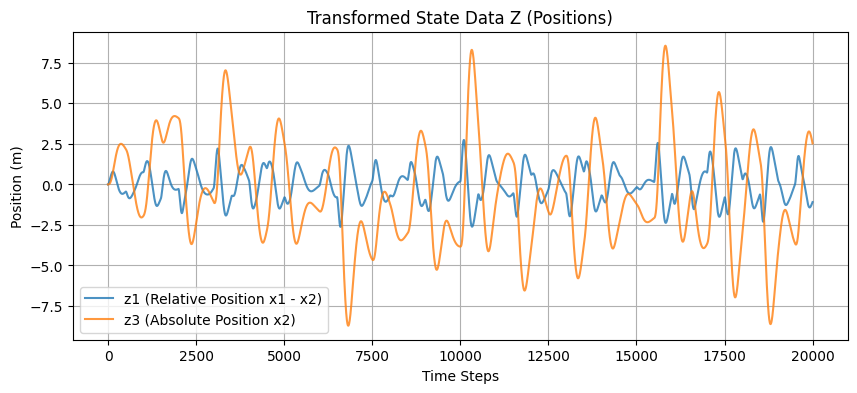

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(z1, label='z1 (Relative Position x1 - x2)', alpha=0.8)
plt.plot(z3, label='z3 (Absolute Position x2)', alpha=0.8)
plt.title("Transformed State Data Z (Positions)")
plt.xlabel("Time Steps")
plt.ylabel("Position (m)")
plt.legend()
plt.grid(True)
plt.show()

Velocities

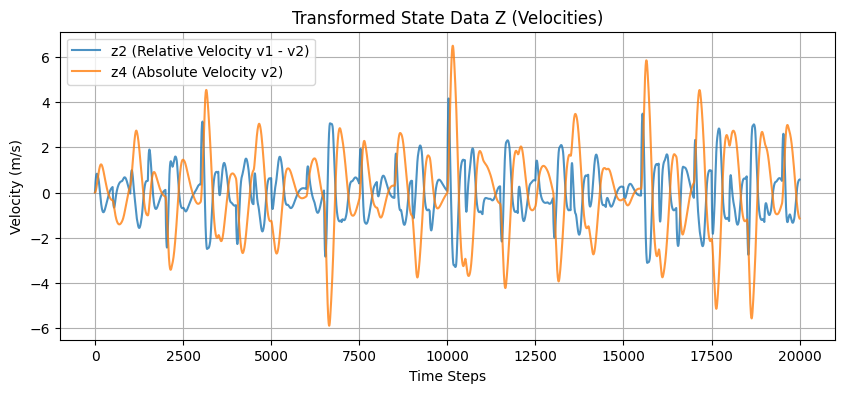

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(z2, label='z2 (Relative Velocity v1 - v2)', alpha=0.8)
plt.plot(z4, label='z4 (Absolute Velocity v2)', alpha=0.8)
plt.title("Transformed State Data Z (Velocities)")
plt.xlabel("Time Steps")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

# Step 6: Stack and Save
We recombine the transformed states and save them to train.

In [7]:
z_vals = np.column_stack((z1, z2, z3, z4))
np.savez("transformed_simulation_data.npz", z_vals=z_vals, u_plot=u_plot)
print("Transformation complete. Saved to 'transformed_simulation_data.npz'")

Transformation complete. Saved to 'transformed_simulation_data.npz'
